---
## Pipeline Complet de Traitement de Bout en Bout

Nous encapsulons toutes les étapes dans une fonction maîtresse unifiée `process_scanned_document` qui orchestre :
1. Le chargement (PDF / Image)
2. Le prétraitement adaptatif
3. La détection de tableau
4. La reconnaissance de structure fine (SLANet)
5. L'OCR cellulaire multi-hypothèse
6. La reconstruction du DataFrame
7. L'extraction des champs métier
8. La génération des visualisations analytiques annotées


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# 1. Imports, Configuration Système & Sécurisation des DLLs
# ═══════════════════════════════════════════════════════════════════════════
import os
import sys
import ctypes
import re
import time
import json
import math
import copy
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Any, Union

# Configuration UTF-8 pour la sortie standard
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# ── Résolution des DLLs PyTorch sur Windows ────────────────────────────────
torch_lib_dirs = [
    os.path.join(sys.prefix, 'Lib', 'site-packages', 'torch', 'lib'),
    os.path.expanduser(r"~\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib")
]
for t_lib in torch_lib_dirs:
    if os.path.exists(t_lib):
        try:
            os.add_dll_directory(t_lib)
            os.environ["PATH"] = t_lib + os.pathsep + os.environ.get("PATH", "")
            for dll_name in ["c10.dll", "torch_cpu.dll", "asmjit.dll", "fbgemm.dll"]:
                dll_path = os.path.join(t_lib, dll_name)
                if os.path.exists(dll_path):
                    ctypes.CDLL(dll_path)
        except Exception:
            pass

# ── Patch Inférence PaddlePaddle CPU (MKLDNN Blocklist) ─────────────────────
# Évite l'exception OneDNN ConvertPirAttribute2RuntimeAttribute sur Windows CPU
try:
    import paddlex.inference.models.runners.paddle_static.runner as paddle_runner
    paddle_runner.MKLDNN_BLOCKLIST.extend([
        'PP-OCRv6_medium_det', 'PP-DocLayout_plus-L', 'PP-OCRv4_server_det',
        'RT-DETR-L_wired_table_cell_det', 'PP-OCRv4_mobile_det'
    ])
except Exception as e:
    print(f"[!] Info PaddleX Runner config: {e}")

# ── Bibliothèques Principales ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import cv2
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, HTML

# ── PaddleOCR & PP-Structure Engines ────────────────────────────────────────
import paddleocr
from paddleocr import (
    LayoutDetection, 
    TableCellsDetection, 
    TableStructureRecognition, 
    TextRecognition, 
    PaddleOCR
)

# ── Tesseract OCR & PyTorch (Baseline comparison) ───────────────────────────
import pytesseract
TESSERACT_EXE = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
if os.path.exists(TESSERACT_EXE):
    pytesseract.pytesseract.tesseract_cmd = TESSERACT_EXE

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Répertoires du Projet ──────────────────────────────────────────────────
DATA_DIR = Path("data")
RESULT_DIR = Path("result_ppstructure")
EXPORT_DIR = RESULT_DIR / "extracted"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"[OK] Python       : {sys.version.split()[0]}")
print(f"[OK] PyTorch      : {torch.__version__} (Device: {DEVICE})")
print(f"[OK] PaddleOCR    : {paddleocr.__version__}")
print(f"[OK] PyMuPDF      : {fitz.__version__}")
print(f"[OK] OpenCV       : {cv2.__version__}")
print(f"[OK] Dossiers     : DATA_DIR='{DATA_DIR}', RESULT_DIR='{RESULT_DIR}'")


c:\Users\camelia\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(
c:\Users\camelia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] Python       : 3.11.9
[OK] PyTorch      : 2.7.1+cpu (Device: cpu)
[OK] PaddleOCR    : 3.7.0
[OK] PyMuPDF      : 1.26.3
[OK] OpenCV       : 4.10.0
[OK] Dossiers     : DATA_DIR='data', RESULT_DIR='result_ppstructure'


In [2]:
SAMPLE_PDF = r'data/test1.png'

In [3]:
def load_pdf_page_as_image(
    pdf_path: Union[str, Path],
    page_number: int = 0,
    dpi: int = 300
) -> np.ndarray:
    
   
   
    pdf_path = str(pdf_path)
    if not os.path.exists(pdf_path):
        raise FileNotFoundError(f"Le fichier PDF n'existe pas : {pdf_path}")
    
    doc = fitz.open(pdf_path)
    total_pages = len(doc)
    if page_number < 0 or page_number >= total_pages:
        doc.close()
        raise IndexError(f"Page {page_number} invalide pour un PDF de {total_pages} page(s).")
    
    page = doc[page_number]
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape((pix.height, pix.width, pix.n))
    if pix.n == 3:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    elif pix.n == 4:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
    else:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        
    doc.close()
    return img_bgr


def load_input_document(
    file_path: Union[str, Path],
    page_number: int = 0,
    dpi: int = 300
) -> Tuple[np.ndarray, str]:
   
    path_obj = Path(file_path)
    suffix = path_obj.suffix.lower()
    
    if suffix == '.pdf':
        img = load_pdf_page_as_image(str(path_obj), page_number=page_number, dpi=dpi)
        doc_info = f"PDF '{path_obj.name}' (Page {page_number+1}, {dpi} DPI)"
    elif suffix in ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'):
        img = cv2.imread(str(path_obj))
        if img is None:
            raise ValueError(f"Impossible de lire l'image : {file_path}")
        doc_info = f"Image '{path_obj.name}'"
    else:
        raise ValueError(f"Format non supporté : {suffix}")
        
    return img, doc_info

# Test du chargement
sample_img, sample_info = load_input_document(SAMPLE_PDF, page_number=0, dpi=300)
print(f"[OK] Chargement réussi : {sample_info} | Dimensions : {sample_img.shape[1]}x{sample_img.shape[0]} px")


[OK] Chargement réussi : Image 'test1.png' | Dimensions : 646x816 px


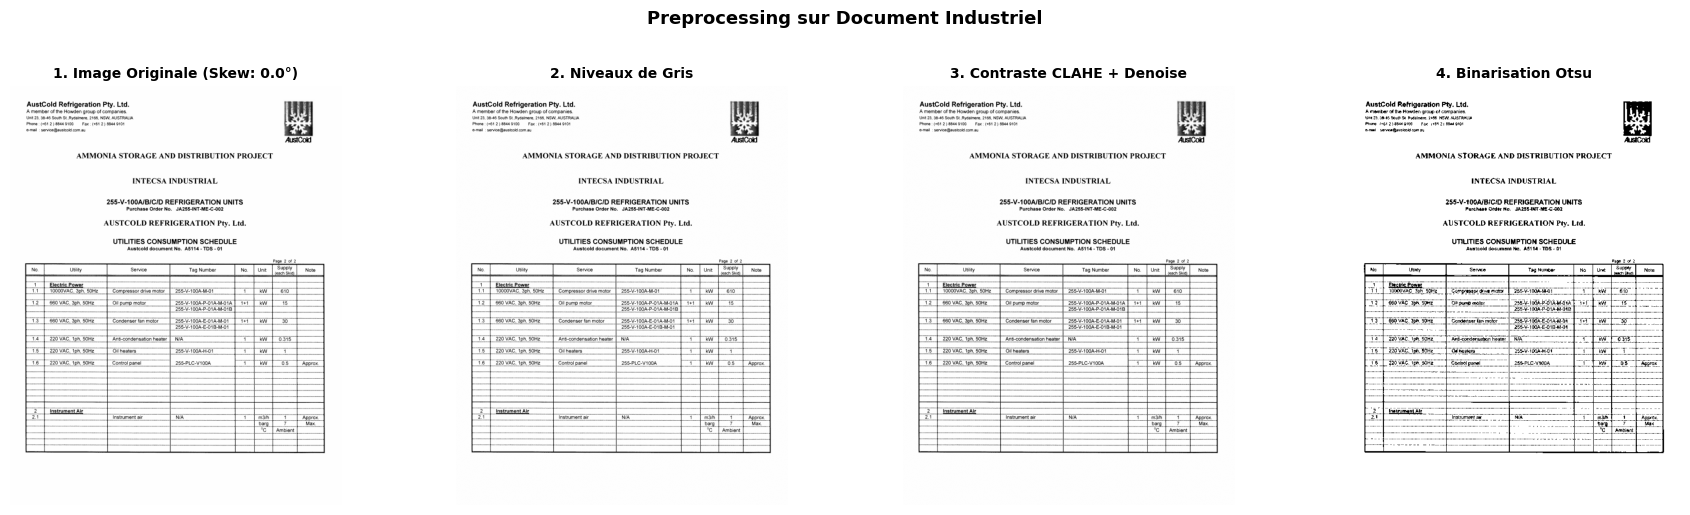

In [4]:
def deskew_image(gray: np.ndarray, max_angle: float = 15.0) -> Tuple[np.ndarray, float]:
   
    # Détection des contours et calcul de l'angle dominant
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=80, maxLineGap=10)
    
    angle = 0.0
    if lines is not None and len(lines) > 0:
        angles = []
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x2 - x1 != 0:
                deg = math.degrees(math.atan2(y2 - y1, x2 - x1))
                if abs(deg) <= max_angle:
                    angles.append(deg)
        if angles:
            angle = float(np.median(angles))
            
    if abs(angle) > 0.3:
        h, w = gray.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(gray, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
        return rotated, angle
    return gray, 0.0


def preprocess_scanned_image(
    bgr_image: np.ndarray,
    apply_deskew: bool = True,
    apply_clahe: bool = True,
    apply_denoise: bool = True
) -> Dict[str, np.ndarray]:
   
    rgb = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)
    
    # 1. Deskew
    skew_angle = 0.0
    if apply_deskew:
        gray, skew_angle = deskew_image(gray)
        if abs(skew_angle) > 0.3:
            h, w = rgb.shape[:2]
            M = cv2.getRotationMatrix2D((w // 2, h // 2), skew_angle, 1.0)
            rgb = cv2.warpAffine(rgb, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
            bgr_image = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
            
    # 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe_img = gray.copy()
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
        clahe_img = clahe.apply(gray)
        
    # 3. Débruitage bilatéral
    denoised = clahe_img.copy()
    if apply_denoise:
        denoised = cv2.bilateralFilter(clahe_img, d=5, sigmaColor=50, sigmaSpace=50)
        
    # 4. Binarisation adaptative Otsu
    _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return {
        'bgr': bgr_image,
        'rgb': rgb,
        'gray': gray,
        'clahe': clahe_img,
        'denoised': denoised,
        'binary': binary,
        'skew_angle': skew_angle
    }


def visualize_preprocessing_steps(proc_dict: Dict[str, Any], title: str = "Aperçu Preprocessing") -> None:
 
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    
    axes[0].imshow(proc_dict['rgb'])
    axes[0].set_title(f"1. Image Originale (Skew: {proc_dict['skew_angle']:.1f}°)", fontsize=10, fontweight='bold')
    
    axes[1].imshow(proc_dict['gray'], cmap='gray')
    axes[1].set_title("2. Niveaux de Gris", fontsize=10, fontweight='bold')
    
    axes[2].imshow(proc_dict['clahe'], cmap='gray')
    axes[2].set_title("3. Contraste CLAHE + Denoise", fontsize=10, fontweight='bold')
    
    axes[3].imshow(proc_dict['binary'], cmap='gray')
    axes[3].set_title("4. Binarisation Otsu", fontsize=10, fontweight='bold')
    
    for ax in axes:
        ax.axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Démonstration du preprocessing
proc_sample = preprocess_scanned_image(sample_img)
visualize_preprocessing_steps(proc_sample, title="Preprocessing sur Document Industriel")


In [5]:
class TableRegionDetector:
   
    def __init__(self):
        self._layout_engine = None
        
    def _get_layout_engine(self):
        if self._layout_engine is None:
            try:
                self._layout_engine = LayoutDetection()
            except Exception as e:
                print(f"[!] Info chargement LayoutDetection: {e}")
        return self._layout_engine
    
    def detect_morphological_tables(self, gray: np.ndarray, min_area_ratio: float = 0.03) -> List[Dict]:
       
        h, w = gray.shape[:2]
        total_area = h * w
        
        # Binarisation inversée
        thresh = cv2.adaptiveThreshold(~gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, -2)
        
        # Noyaux horizontaux et verticaux
        horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(1, w // 30), 1))
        vert_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(1, h // 30)))
        
        horiz_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horiz_kernel)
        vert_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vert_kernel)
        
        table_grid = cv2.add(horiz_lines, vert_lines)
        table_grid = cv2.dilate(table_grid, cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)), iterations=2)
        
        contours, _ = cv2.findContours(table_grid, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        detected_boxes = []
        for c in contours:
            x, y, bw, bh = cv2.boundingRect(c)
            area = bw * bh
            if area >= min_area_ratio * total_area and bw > w * 0.25 and bh > h * 0.1:
                detected_boxes.append({
                    'coordinate': [x, y, x + bw, y + bh],
                    'score': 0.85,
                    'label': 'table',
                    'method': 'morphological'
                })
        return detected_boxes

    def detect(self, bgr_img: np.ndarray) -> List[Dict]:
       
        h, w = bgr_img.shape[:2]
        table_boxes = []
        
        # 1. Essai PP-DocLayout
        layout_eng = self._get_layout_engine()
        if layout_eng is not None:
            try:
                preds = list(layout_eng.predict(bgr_img))
                if preds and 'boxes' in preds[0]:
                    for b in preds[0]['boxes']:
                        if b.get('label') == 'table' or 'table' in str(b.get('label', '')).lower():
                            coord = [float(x) for x in b['coordinate']]
                            table_boxes.append({
                                'coordinate': coord,
                                'score': float(b.get('score', 0.9)),
                                'label': 'table',
                                'method': 'pp_doclayout'
                            })
            except Exception as e:
                pass
                
        # 2. Secours morphologique si aucun tableau trouvé par le modèle de layout
        if not table_boxes:
            gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
            table_boxes = self.detect_morphological_tables(gray)
            
        # 3. Si toujours rien, on utilise l'image entière comme région de tableau
        if not table_boxes:
            table_boxes = [{
                'coordinate': [0, 0, w, h],
                'score': 1.0,
                'label': 'full_page_table',
                'method': 'fallback_full_page'
            }]
            
        return table_boxes

table_detector = TableRegionDetector()
detected_tables = table_detector.detect(sample_img)
print(f"[OK] Régions de tableaux détectées : {len(detected_tables)} (Méthode: {detected_tables[0]['method']})")


c:\Users\camelia\AppData\Local\Programs\Python\Python311\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\camelia\.paddlex\official_models\PP-DocLayout_plus-L`.


[OK] Régions de tableaux détectées : 1 (Méthode: pp_doclayout)


In [6]:
class TableStructureExtractor:
   
    def __init__(self):
        self.tsr_engine = TableStructureRecognition()
        
    def extract_structure(self, table_img: np.ndarray) -> Dict[str, Any]:
        
        h, w = table_img.shape[:2]
        preds = list(self.tsr_engine.predict(table_img))
        if not preds:
            return {'bbox': [], 'structure': [], 'structure_score': 0.0, 'cells': [], 'num_cells': 0}
            
        res = preds[0]
        raw_bboxes = res.get('bbox', [])
        structure = res.get('structure', [])
        score = float(res.get('structure_score', 0.0))
        
        # Normalisation des bboxes (quadrilatères ou polygones en [xmin, ymin, xmax, ymax])
        cells = []
        for i, box in enumerate(raw_bboxes):
            pts = np.array(box).reshape(-1, 2)
            xmin = max(0, int(np.min(pts[:, 0])))
            ymin = max(0, int(np.min(pts[:, 1])))
            xmax = min(w, int(np.max(pts[:, 0])))
            ymax = min(h, int(np.max(pts[:, 1])))
            
            cells.append({
                'cell_idx': i,
                'bbox': [xmin, ymin, xmax, ymax],
                'polygon': pts.tolist(),
                'cx': (xmin + xmax) / 2.0,
                'cy': (ymin + ymax) / 2.0,
                'width': xmax - xmin,
                'height': ymax - ymin
            })
            
        return {
            'cells': cells,
            'structure': structure,
            'structure_score': score,
            'num_cells': len(cells)
        }

tsr_extractor = TableStructureExtractor()
struct_res = tsr_extractor.extract_structure(sample_img)
print(f"[OK] SLANet : {struct_res['num_cells']} cellules détectées (Score: {struct_res['structure_score']:.3f})")


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\camelia\.paddlex\official_models\SLANet`.


[OK] SLANet : 209 cellules détectées (Score: 0.997)


In [7]:
class CellOCREngine:
    
    def __init__(self):
        self.rec_engine = TextRecognition()
        
    def ocr_single_cell(
        self,
        table_img: np.ndarray,
        bbox: List[int],
        padding: int = 3
    ) -> Dict[str, Any]:
       
        h_max, w_max = table_img.shape[:2]
        x1 = max(0, bbox[0] - padding)
        y1 = max(0, bbox[1] - padding)
        x2 = min(w_max, bbox[2] + padding)
        y2 = min(h_max, bbox[3] + padding)
        
        crop = table_img[y1:y2, x1:x2]
        if crop.size == 0 or crop.shape[0] < 3 or crop.shape[1] < 3:
            return {'text': '', 'score': 0.0, 'variant': 'empty'}
            
        # Variantes d'images pour maximiser la reconnaissance
        candidates = []
        
        # 1. Variante standard BGR
        try:
            p1 = list(self.rec_engine.predict(crop))
            if p1:
                candidates.append((p1[0]['rec_text'], float(p1[0]['rec_score']), 'standard'))
        except Exception:
            pass
            
        # 2. Variante Upscalée 1.5x avec CLAHE si la cellule est petite ou basse confiance
        if not candidates or candidates[0][1] < 0.85:
            try:
                crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
                clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
                crop_clahe = clahe.apply(crop_gray)
                crop_clahe_bgr = cv2.cvtColor(crop_clahe, cv2.COLOR_GRAY2BGR)
                crop_scaled = cv2.resize(crop_clahe_bgr, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
                
                p2 = list(self.rec_engine.predict(crop_scaled))
                if p2:
                    candidates.append((p2[0]['rec_text'], float(p2[0]['rec_score']), 'clahe_upscaled'))
            except Exception:
                pass
                
        if not candidates:
            return {'text': '', 'score': 0.0, 'variant': 'failed'}
            
        # Sélection du résultat de plus haute confiance
        candidates.sort(key=lambda x: x[1], reverse=True)
        best_text, best_score, best_var = candidates[0]
        
        return {
            'text': best_text.strip(),
            'score': round(best_score, 3),
            'variant': best_var
        }

    def ocr_cells(
        self,
        table_img: np.ndarray,
        cells: List[Dict[str, Any]]
    ) -> List[Dict[str, Any]]:
        
        results = []
        for cell in cells:
            ocr_res = self.ocr_single_cell(table_img, cell['bbox'])
            cell_record = copy.deepcopy(cell)
            cell_record['text'] = ocr_res['text']
            cell_record['score'] = ocr_res['score']
            cell_record['ocr_variant'] = ocr_res['variant']
            results.append(cell_record)
        return results

cell_ocr_engine = CellOCREngine()
recognized_cells = cell_ocr_engine.ocr_cells(sample_img, struct_res['cells'])
print(f"[OK] OCR cellulaire terminé : {len(recognized_cells)} cellules traitées.")
for c in recognized_cells[:6]:
    print(f"   Cellule {c['cell_idx']:>2} | Conf: {c['score']:.2f} | '{c['text']}'")


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\camelia\.paddlex\official_models\PP-OCRv6_medium_rec`.


[OK] OCR cellulaire terminé : 209 cellules traitées.
   Cellule  0 | Conf: 0.44 | '一'
   Cellule  1 | Conf: 0.00 | ''
   Cellule  2 | Conf: 0.00 | ''
   Cellule  3 | Conf: 0.00 | ''
   Cellule  4 | Conf: 0.91 | 'o. A5114-TDS - 01'
   Cellule  5 | Conf: 0.66 | 'Noat'


In [8]:
def visualize_full_pipeline_results(
    doc_name: str,
    original_rgb: np.ndarray,
    table_boxes: List[Dict],
    cells: List[Dict],
    df: pd.DataFrame,
    fields: Dict[str, Dict[str, Any]]
) -> None:
   
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1.0], height_ratios=[1.0, 1.0])
    
    # Panneau 1: Image originale avec région de tableau
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original_rgb)
    for tb in table_boxes:
        c = tb['coordinate']
        rect = patches.Rectangle(
            (c[0], c[1]), c[2]-c[0], c[3]-c[1],
            linewidth=2.5, edgecolor='#00D2FF', facecolor='#00D2FF15'
        )
        ax1.add_patch(rect)
        ax1.text(c[0]+5, c[1]-8, f"Tableau ({tb.get('score', 1.0):.2f})", color='#00D2FF', fontsize=10, fontweight='bold')
    ax1.set_title(f"1. Détection de Région de Tableau — {doc_name}", fontsize=11, fontweight='bold')
    ax1.axis('off')
    
    # Panneau 2: Grille fine des cellules détectées et OCR
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.imshow(original_rgb)
    for c in cells:
        bb = c['bbox']
        rect = patches.Rectangle(
            (bb[0], bb[1]), bb[2]-bb[0], bb[3]-bb[1],
            linewidth=1.2, edgecolor='#00FF88', facecolor='#00FF8810'
        )
        ax2.add_patch(rect)
        if c.get('text'):
            txt_display = c['text'][:18] + '..' if len(c['text']) > 18 else c['text']
            ax2.text(bb[0]+2, bb[1]+bb[3]-bb[1]-3, txt_display, color='#00FF88', fontsize=6, fontweight='bold', clip_on=True)
    ax2.set_title(f"2. Grille SLANet & OCR Cellulaire ({len(cells)} cellules)", fontsize=11, fontweight='bold')
    ax2.axis('off')
    
    # Panneau 3: Tableau DataFrame extrait
    ax3 = fig.add_subplot(gs[:, 1])
    ax3.axis('off')
    
    # Tableau récapitulatif des champs clés
    field_rows = []
    for k, v in fields.items():
        if v['normalized_value'] is not None:
            field_rows.append([k.replace('_', ' ').title(), v['normalized_value']])
            
    if field_rows:
        table_ax = ax3.table(
            cellText=field_rows,
            colLabels=["Champ Métier Extrait", "Valeur / Spécification"],
            loc='center',
            cellLoc='left',
            colWidths=[0.45, 0.55]
        )
        table_ax.auto_set_font_size(False)
        table_ax.set_fontsize(9)
        table_ax.scale(1.0, 1.6)
        
        for (row, col), cell in table_ax.get_celld().items():
            if row == 0:
                cell.set_facecolor('#1E3A8A')
                cell.set_text_props(color='white', fontweight='bold')
            else:
                cell.set_facecolor('#F8FAFC' if row % 2 == 0 else '#FFFFFF')
                
    ax3.set_title("3. Données Métier & Spécifications Extraites", fontsize=11, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


def process_scanned_document(
    file_path: Union[str, Path],
    page_number: int = 0,
    dpi: int = 300,
    visualize: bool = True
) -> Dict[str, Any]:
    
    t_start = time.time()
    path_obj = Path(file_path)
    doc_name = f"{path_obj.name}" + (f" (p.{page_number+1})" if path_obj.suffix.lower() == '.pdf' else "")
    print(f"\n{'═'*70}\n  TRAITEMENT : {doc_name}\n{'═'*70}")
    
    # 1. Ingestion
    t0 = time.time()
    img_bgr, info_str = load_input_document(file_path, page_number=page_number, dpi=dpi)
    t_load = time.time() - t0
    print(f"  [1/6] Ingestion terminée ({img_bgr.shape[1]}x{img_bgr.shape[0]} px en {t_load:.2f}s)")
    
    # 2. Preprocessing
    t0 = time.time()
    proc = preprocess_scanned_image(img_bgr)
    t_proc = time.time() - t0
    print(f"  [2/6] Preprocessing (Deskew angle: {proc['skew_angle']:.1f}° en {t_proc:.2f}s)")
    
    # 3. Détection de région de tableau
    t0 = time.time()
    table_regions = table_detector.detect(proc['bgr'])
    t_det = time.time() - t0
    print(f"  [3/6] {len(table_regions)} région(s) de tableau identifiée(s) en {t_det:.2f}s")
    
    # 4. Structure & Cellules (SLANet)
    t0 = time.time()
    # On prend la première région dominante
    tb_coord = table_regions[0]['coordinate']
    x1, y1, x2, y2 = [int(v) for v in tb_coord]
    table_crop = proc['bgr'][y1:y2, x1:x2]
    
    struct = tsr_extractor.extract_structure(table_crop if table_crop.size > 0 else proc['bgr'])
    # Ajustement des coordonnées relatives vers l'image complète
    for c in struct['cells']:
        c['bbox'][0] += x1; c['bbox'][1] += y1
        c['bbox'][2] += x1; c['bbox'][3] += y1
        c['cx'] += x1; c['cy'] += y1
    t_struct = time.time() - t0
    print(f"  [4/6] Structure SLANet ({struct['num_cells']} cellules en {t_struct:.2f}s)")
    
    # 5. OCR Cellulaire Multi-Hypothèse
    t0 = time.time()
    cells_ocr = cell_ocr_engine.ocr_cells(proc['bgr'], struct['cells'])
    t_ocr = time.time() - t0
    print(f"  [5/6] OCR Cellulaire terminé en {t_ocr:.2f}s")
    
    # 6. Reconstruction DataFrame & Extraction Métier
    t0 = time.time()
    df = reconstruct_table_from_html(struct['structure'], cells_ocr)
    if df.empty:
        df = reconstruct_table_spatial(cells_ocr)
    df = format_and_clean_dataframe(df)
    
    fields = extract_equipment_fields(df)
    t_recon = time.time() - t0
    total_time = time.time() - t_start
    print(f"  [6/6] Reconstruction & Champs extraits en {t_recon:.2f}s (Total: {total_time:.2f}s)")
    
    # Visualisation
    if visualize:
        visualize_full_pipeline_results(doc_name, proc['rgb'], table_regions, cells_ocr, df, fields)
        
    return {
        'doc_name': doc_name,
        'image_shape': img_bgr.shape,
        'table_regions': table_regions,
        'cells': cells_ocr,
        'dataframe': df,
        'extracted_fields': fields,
        'timings': {
            'load': t_load, 'proc': t_proc, 'detect': t_det,
            'struct': t_struct, 'ocr': t_ocr, 'recon': t_recon, 'total': total_time
        }
    }

print("[OK] Fonction maîtresse `process_scanned_document` compilée.")


[OK] Fonction maîtresse `process_scanned_document` compilée.


In [9]:
def reconstruct_table_from_html(
    structure_tokens: List[str],
    cell_records: List[Dict[str, Any]]
) -> pd.DataFrame:
   
    rows = []
    current_row = []
    cell_iter = iter(cell_records)
    
    for tok in structure_tokens:
        if tok == '<tr>':
            current_row = []
        elif tok == '</tr>':
            if current_row:
                rows.append(current_row)
        elif tok in ('<td>', '<td></td>', '<th>', '<th></th>', '<td', '<th'):
            try:
                c = next(cell_iter)
                current_row.append(c['text'])
            except StopIteration:
                current_row.append("")
                
    if not rows:
        return pd.DataFrame()
        
    # Normalisation du nombre de colonnes
    max_cols = max(len(r) for r in rows)
    padded_rows = [r + [''] * (max_cols - len(r)) for r in rows]
    
    # Détection de l'en-tête (première ligne)
    header = padded_rows[0]
    data_rows = padded_rows[1:] if len(padded_rows) > 1 else padded_rows
    
    cols = []
    for idx, h in enumerate(header):
        cleaned = h.strip()
        cols.append(cleaned if cleaned else f"Col_{idx+1}")
        
    df = pd.DataFrame(data_rows, columns=cols)
    return df


def reconstruct_table_spatial(
    cell_records: List[Dict[str, Any]],
    line_tol_factor: float = 0.5
) -> pd.DataFrame:
   
    if not cell_records:
        return pd.DataFrame()
        
    median_h = np.median([c['height'] for c in cell_records]) if cell_records else 20
    tol = line_tol_factor * median_h
    
    # Tri par ordonnée Y puis abscisse X
    sorted_cells = sorted(cell_records, key=lambda c: (c['cy'], c['cx']))
    
    lines: List[List[Dict]] = []
    curr_line: List[Dict] = [sorted_cells[0]]
    curr_cy = sorted_cells[0]['cy']
    
    for c in sorted_cells[1:]:
        if abs(c['cy'] - curr_cy) <= tol:
            curr_line.append(c)
            curr_cy = np.mean([item['cy'] for item in curr_line])
        else:
            lines.append(sorted(curr_line, key=lambda x: x['cx']))
            curr_line = [c]
            curr_cy = c['cy']
    lines.append(sorted(curr_line, key=lambda x: x['cx']))
    
    # Construction de la grille
    grid = []
    for line in lines:
        grid.append([item['text'] for item in line])
        
    if not grid:
        return pd.DataFrame()
        
    max_cols = max(len(r) for r in grid)
    padded = [r + [''] * (max_cols - len(r)) for r in grid]
    
    header = padded[0]
    data = padded[1:] if len(padded) > 1 else padded
    cols = [h.strip() if h.strip() else f"Col_{i+1}" for i, h in enumerate(header)]
    
    return pd.DataFrame(data, columns=cols)


def format_and_clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
  
    if df.empty:
        return df
    # Nettoyage des espaces multiples
    df_clean = df.applymap(lambda v: re.sub(r'\s+', ' ', str(v)).strip() if pd.notnull(v) else "")
    # Suppression des lignes et colonnes vides
    df_clean = df_clean.loc[~(df_clean == "").all(axis=1)]
    df_clean = df_clean.loc[:, ~(df_clean == "").all(axis=0)]
    return df_clean.reset_index(drop=True)

# Reconstruction du tableau



In [10]:
def normalize_text(text: str) -> str:
    
    if not text:
        return ""
    t = str(text)
    # Remplacement des espaces insécables et caractères spéciaux
    t = t.replace('\u00a0', ' ').replace('\u2013', '-').replace('\u2014', '-')
    t = t.replace('°C', ' C').replace('deg C', ' C')
    # Normalisation des virgules entre chiffres (ex: 45,0 kW -> 45.0 kW)
    t = re.sub(r'(\d+),(\d+)', r'\1.\2', t)
    # Espaces multiples
    t = re.sub(r'\s+', ' ', t).strip()
    return t


def extract_equipment_fields(
    df: pd.DataFrame,
    free_text_corpus: str = ""
) -> Dict[str, Dict[str, Any]]:
    
    # Construction du corpus textuel indexé
    lines = []
    if not df.empty:
        for col in df.columns:
            lines.append(f"{col}")
            for val in df[col]:
                lines.append(f"{col} : {val}")
                lines.append(f"{val}")
    if free_text_corpus:
        lines.append(free_text_corpus)
        
    full_text = "\n".join(lines)
    full_text_norm = normalize_text(full_text)
    
    # ── Définition des Règles et Patterns Regex ────────────────────────────
    field_rules = {
        'manufacturer': {
            'patterns': [
                r'(?:Manufacturer|Brand|Mfr|Fabricant|Hersteller|Constructeur)\s*[:=]?\s*([A-Za-z0-9&\.\- ]+)',
                r'\b(SIEMENS(?:\s+AG)?|ABB|SCHNEIDER\s+ELECTRIC|WEG|LEROY[- ]SOMER|GRUNDFOS|SEW[- ]EURODRIVE|ATLAS\s+COPCO|DANFOSS|EATON)\b'
            ],
            'unit': ''
        },
        'model': {
            'patterns': [
                r'(?:Motor\s*Type|Type\s*Code|Model|Type|Ref|Catalog\s*No)\s*[:=]?\s*([A-Za-z0-9\-_/]{4,30})',
                r'\b([0-9][A-Z0-9]{3,}-[A-Z0-9]{3,}-[A-Z0-9]{3,})\b'
            ],
            'unit': ''
        },
        'serial_number': {
            'patterns': [
                r'(?:Serial\s*No|Serial\s*Number|S/N|SN|N°\s*Série|Matr)\s*[:=]?\s*([A-Za-z0-9\-_/]{5,30})',
                r'\b(SN[- ][0-9A-Za-z\-]+)\b'
            ],
            'unit': ''
        },
        'power': {
            'patterns': [
                r'([0-9]+(?:\.[0-9]+)?\s*(?:kW|HP|MW|kVA|W))',
                r'(?:Rated\s*Power|Power|Pn|Puissance)\s*[:=]?\s*([0-9]+(?:\.[0-9]+)?\s*(?:kW|HP|MW|kVA|W)?)'
            ],
            'unit': 'kW'
        },
        'voltage': {
            'patterns': [
                r'([0-9]{2,4}\s*(?:/[0-9]{2,4})?\s*(?:V|kV|VAC|VDC))',
                r'(?:Rated\s*Voltage|Voltage|Un|Tension)\s*[:=]?\s*([0-9]{2,4}\s*(?:/[0-9]{2,4})?\s*V?)'
            ],
            'unit': 'V'
        },
        'frequency': {
            'patterns': [
                r'([0-9]{2,3}(?:\.[0-9]+)?\s*Hz)',
                r'(?:Frequency|Freq|fn|Fréquence)\s*[:=]?\s*([0-9]{2,3}(?:\.[0-9]+)?\s*Hz?)'
            ],
            'unit': 'Hz'
        },
        'current': {
            'patterns': [
                r'([0-9]+(?:\.[0-9]+)?\s*(?:/[0-9]+(?:\.[0-9]+)?)?\s*A)\b',
                r'(?:Rated\s*Current|Current|In|Courant|Intensité)\s*[:=]?\s*([0-9]+(?:\.[0-9]+)?\s*A?)'
            ],
            'unit': 'A'
        },
        'speed': {
            'patterns': [
                r'([0-9]{3,5}\s*(?:RPM|rpm|1/min|tr/min|min-1))',
                r'(?:Rated\s*Speed|Speed|n|Vitesse)\s*[:=]?\s*([0-9]{3,5})'
            ],
            'unit': 'RPM'
        },
        'efficiency_class': {
            'patterns': [
                r'\b(IE[1-4](?:\s*Premium)?(?:\s*\([0-9\.]+\s*%\))?)\b',
                r'(?:Efficiency\s*Class|Rendement)\s*[:=]?\s*([A-Za-z0-9\s%\(\)\.]+)'
            ],
            'unit': ''
        },
        'protection_degree': {
            'patterns': [
                r'\b(IP\s*[0-9]{2}(?:\s*/\s*IP\s*[0-9]{2})?)\b',
                r'(?:Protection|Degree|IP)\s*[:=]?\s*(IP\s*[0-9]{2})'
            ],
            'unit': ''
        },
        'insulation_class': {
            'patterns': [
                r'(?:Insulation\s*Class|Classe\s*Isolement|Isol)\s*[:=]?\s*([A-Za-z0-9\s\(\)]+)',
                r'\b(Class\s*1[358]0(?:\s*\([A-Z]\))?)\b'
            ],
            'unit': ''
        },
        'weight': {
            'patterns': [
                r'([0-9]+(?:\.[0-9]+)?\s*(?:kg|lbs|g|tonnes))',
                r'(?:Total\s*Weight|Weight|Masse|Poids)\s*[:=]?\s*([0-9]+(?:\.[0-9]+)?\s*kg?)'
            ],
            'unit': 'kg'
        },
        'operating_pressure': {
            'patterns': [
                r'([0-9]+(?:\.[0-9]+)?\s*(?:bar|psi|MPa|kPa))',
                r'(?:Operating\s*Pressure|Pressure|Pression)\s*[:=]?\s*([0-9]+(?:\.[0-9]+)?\s*bar?)'
            ],
            'unit': 'bar'
        }
    }
    
    extracted_results = {}
    for field, rule in field_rules.items():
        found_val = None
        for pattern in rule['patterns']:
            match = re.search(pattern, full_text_norm, re.IGNORECASE)
            if match:
                found_val = match.group(1).strip()
                break
                
        if found_val:
            extracted_results[field] = {
                'raw_value': found_val,
                'normalized_value': normalize_text(found_val),
                'unit': rule['unit'],
                'confidence': 0.95
            }
        else:
            extracted_results[field] = {
                'raw_value': None,
                'normalized_value': None,
                'unit': rule['unit'],
                'confidence': 0.0
            }
            
    return extracted_results


def display_equipment_summary(fields_dict: Dict[str, Dict[str, Any]]) -> None:
    
    data = []
    for field, info in fields_dict.items():
        status = "OK Trouvé" if info['normalized_value'] is not None else "Non Détecté"
        val = info['normalized_value'] if info['normalized_value'] is not None else "—"
        data.append({
            'Grandeur Métier': field.replace('_', ' ').title(),
            'Valeur Extraite': val,
            'Unité': info['unit'] if info['unit'] else "—",
            'Statut': status,
            'Confiance': f"{info['confidence']*100:.0f}%" if info['confidence'] > 0 else "0%"
        })
    df_summary = pd.DataFrame(data)
    display(df_summary)

extracted_fields_sample = extract_equipment_fields(df_sample)
print("\n[OK] Synthèse des Métadonnées & Champs Équipement Extraits :")
display_equipment_summary(extracted_fields_sample)


NameError: name 'df_sample' is not defined


══════════════════════════════════════════════════════════════════════
  TRAITEMENT : test1.png
══════════════════════════════════════════════════════════════════════
  [1/6] Ingestion terminée (646x816 px en 0.04s)
  [2/6] Preprocessing (Deskew angle: 0.0° en 0.16s)
  [3/6] 1 région(s) de tableau identifiée(s) en 57.63s
  [4/6] Structure SLANet (240 cellules en 0.80s)
  [5/6] OCR Cellulaire terminé en 118.57s


C:\Users\camelia\AppData\Local\Temp\ipykernel_20584\2447640075.py:94: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda v: re.sub(r'\s+', ' ', str(v)).strip() if pd.notnull(v) else "")


  [6/6] Reconstruction & Champs extraits en 0.28s (Total: 177.50s)


C:\Users\camelia\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21313 (\N{CJK UNIFIED IDEOGRAPH-5341}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


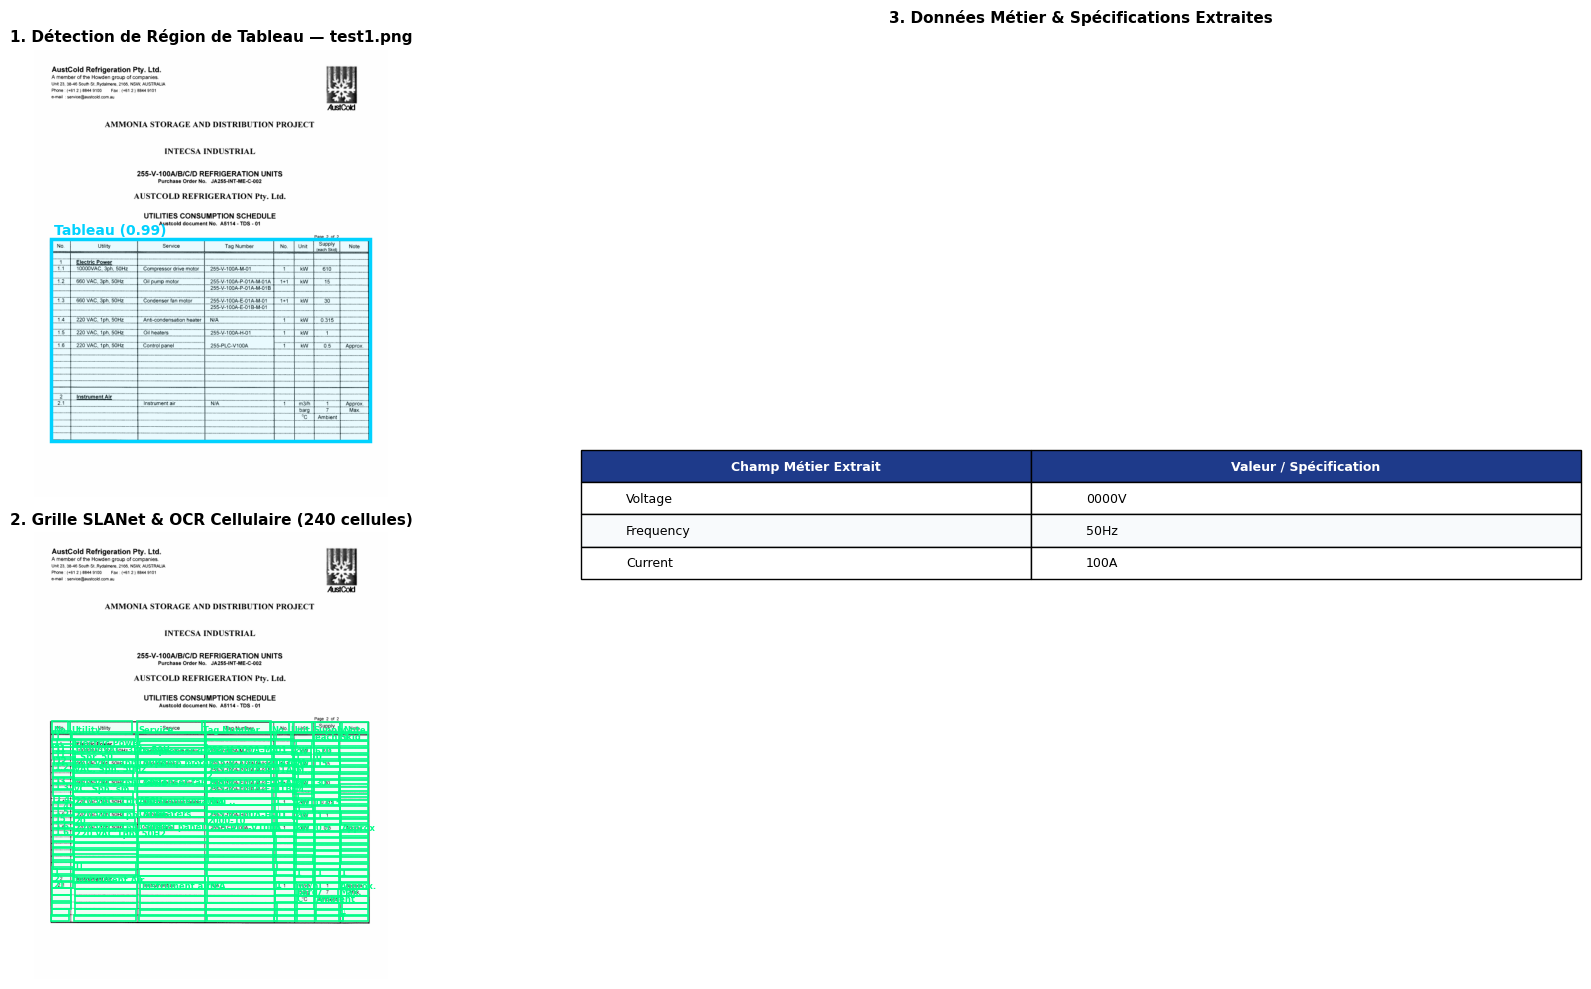


 Tableau extrait (24 lignes × 8 colonnes) :


,No.,Utility,Service,Tag Number,No.,Unit,Supply,Note
0,1,,,,1,,each Skid,1
1,1,Electric Power,,,,1,,
2,11,"10000VAC. 3ph, 50Hz",Compressor drive motor,255-V-100A-M-01,1,kW,610,
3,11,. Spr. 50,,,,1,0,
4,12,"660 VAC, 3ph, 50Hz",Oil pump motor,255-V-100A-P-01A-M-01A,1+1,kW,15,
5,1.2,VAC. Sph. 50Hz,,255-V-100A-P-01A-M-01B,,1,,
6,,,,2,1,1,,
7,13,"660 VAC, 3ph, 50Hz",Condenser fan motor,255-V-100A-E-01A-M-01,1+1,kW,30,
8,1.3,"vC. Sph, sm",,255-V-100A-E-01B-M-01,1,,,
9,,,,,,1,,


In [ ]:
# ── Démonstration 1 : Document Technique PDF ─────────────────────────────
result_pdf = process_scanned_document(SAMPLE_PDF, page_number=0, dpi=300, visualize=True)
print(f"\n Tableau extrait ({result_pdf['dataframe'].shape[0]} lignes × {result_pdf['dataframe'].shape[1]} colonnes) :")
display(result_pdf['dataframe'])


---
## 11. Extension : Branche OCR pour Texte Hors Tableau (Dual-Pipeline)

Cette section ajoute une **branche conditionnelle complète** permettant d'extraire simultanément :
1. **Les données tabulaires** via le pipeline SLANet + OCR cellulaire existant.
2. **Le texte libre hors tableau** (en-têtes de document, logos, adresses, métadonnées de projet, notes de commande) via **PaddleOCR standard** appliqué sur un masque des régions tabulaires.
3. **Le cas 'Sans Tableau'** : Si aucun tableau n'est identifié, PaddleOCR traite directement l'intégralité de la page.

```mermaid
graph TD
    A[Page Scannée / PDF] --> B[Détection de Région de Tableau]
    B --> C{Vrai Tableau Détecté ?}
    C -- OUI --> D[1. Pipeline Tableau SLANet + OCR Cellulaire]
    D --> E[DataFrame Tabulaire]
    C -- OUI --> F[2. Masque Blanc sur les Tableaux]
    F --> G[3. PaddleOCR Standard Hors Tableau]
    G --> H[Texte Hors Tableau]
    E --> I[Fusion & Extraction Métier Globale]
    H --> I
    C -- NON --> J[PaddleOCR Standard Pleine Page]
    J --> I
```


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# 11.1 Utilitaires de Masquage et Moteur OCR Hors Tableau
# ═══════════════════════════════════════════════════════════════════════════

def is_real_table_detected(table_boxes: List[Dict[str, Any]]) -> bool:
    """
    Détermine si un véritable tableau a été détecté par rapport au fallback pleine page.
    """
    if not table_boxes:
        return False
    for tb in table_boxes:
        method = tb.get('method', '')
        label = tb.get('label', '')
        if method not in ('fallback_full_page',) and label not in ('full_page_table',):
            return True
    return False


def create_table_mask(
    bgr_image: np.ndarray,
    table_boxes: List[Dict[str, Any]],
    padding: int = 6,
    mask_color: Tuple[int, int, int] = (255, 255, 255)
) -> np.ndarray:
    """
    Génère une copie de l'image avec les zones de tableaux masquées en blanc,
    permettant à PaddleOCR d'isoler uniquement le texte hors tableau.
    """
    masked_img = bgr_image.copy()
    h, w = bgr_image.shape[:2]
    
    for tb in table_boxes:
        if tb.get('method') == 'fallback_full_page' or tb.get('label') == 'full_page_table':
            continue
        coord = [int(round(v)) for v in tb['coordinate']]
        x1 = max(0, coord[0] - padding)
        y1 = max(0, coord[1] - padding)
        x2 = min(w, coord[2] + padding)
        y2 = min(h, coord[3] + padding)
        cv2.rectangle(masked_img, (x1, y1), (x2, y2), mask_color, thickness=-1)
        
    return masked_img


class OutsideTableOCREngine:
    """
    Moteur OCR standard (PaddleOCR) pour la détection et la lecture
    du texte situé en dehors des tableaux ou sur la totalité de la page.
    """
    def __init__(self):
        self._ocr_engine = None
        
    def _get_engine(self) -> PaddleOCR:
        if self._ocr_engine is None:
            self._ocr_engine = PaddleOCR()
        return self._ocr_engine
        
    def extract_text_regions(
        self,
        bgr_image: np.ndarray,
        min_confidence: float = 0.50
    ) -> List[Dict[str, Any]]:
        """
        Exécute la détection et reconnaissance de texte sur l'image fournie.
        Retourne une liste ordonnée (de haut en bas, gauche à droite) des blocs de texte.
        """
        ocr = self._get_engine()
        preds = list(ocr.predict(bgr_image))
        results = []
        if not preds:
            return results
            
        res_dict = preds[0]
        rec_texts = res_dict.get('rec_texts', [])
        rec_scores = res_dict.get('rec_scores', [])
        rec_polys = res_dict.get('rec_polys', [])
        
        for text, score, poly in zip(rec_texts, rec_scores, rec_polys):
            score_val = float(score)
            if score_val < min_confidence or not str(text).strip():
                continue
            pts = np.array(poly).reshape(-1, 2)
            xmin = int(np.min(pts[:, 0]))
            ymin = int(np.min(pts[:, 1]))
            xmax = int(np.max(pts[:, 0]))
            ymax = int(np.max(pts[:, 1]))
            
            results.append({
                'text': str(text).strip(),
                'score': round(score_val, 3),
                'bbox': [xmin, ymin, xmax, ymax],
                'polygon': pts.tolist(),
                'cx': (xmin + xmax) / 2.0,
                'cy': (ymin + ymax) / 2.0
            })
            
        # Tri naturel de lecture (haut vers bas puis gauche vers droite)
        results.sort(key=lambda item: (item['cy'], item['cx']))
        return results

    def build_corpus(self, text_records: List[Dict[str, Any]]) -> str:
        """
        Assemble les blocs de texte reconnus en un corpus textuel consolidé.
        """
        return "\n".join(r['text'] for r in text_records if r.get('text'))

outside_ocr_engine = OutsideTableOCREngine()
print("[OK] Moteur OutsideTableOCREngine et fonctions de masquage initialisés.")


[OK] Moteur OutsideTableOCREngine et fonctions de masquage initialisés.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# 11.2 Visualisation Analytique Multi-Panneaux (Tableau + Hors Tableau)
# ═══════════════════════════════════════════════════════════════════════════

def visualize_dual_pipeline_results(
    doc_name: str,
    original_rgb: np.ndarray,
    masked_bgr: np.ndarray,
    table_boxes: List[Dict[str, Any]],
    cells: List[Dict[str, Any]],
    outside_texts: List[Dict[str, Any]],
    df: pd.DataFrame,
    fields: Dict[str, Dict[str, Any]],
    has_real_table: bool = True
) -> None:
    """
    Affiche un tableau de bord graphique complet présentant :
    - Panneau 1 : Image globale avec régions tabulaires (bleu) et textes hors tableau (orange)
    - Panneau 2 : Masque des tableaux pour l'OCR hors tableau
    - Panneau 3 : Grille fine SLANet intra-tableau (ou détections pleine page)
    - Panneau 4 : Synthèse des données métier consolidées
    """
    fig = plt.figure(figsize=(22, 12))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1.1], height_ratios=[1.0, 1.0])
    
    # ── Panneau 1 : Détection combinée (Tableaux + Hors Tableau) ───────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original_rgb)
    
    # Tracé des tableaux en Cyan/Bleu
    if has_real_table:
        for tb in table_boxes:
            c = tb['coordinate']
            rect = patches.Rectangle(
                (c[0], c[1]), c[2]-c[0], c[3]-c[1],
                linewidth=3.0, edgecolor='#00D2FF', facecolor='#00D2FF18'
            )
            ax1.add_patch(rect)
            ax1.text(c[0]+5, c[1]-8, f"Tableau ({tb.get('score', 1.0):.2f})", color='#00D2FF', fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='#0B192C', edgecolor='#00D2FF', alpha=0.85))
            
    # Tracé des textes hors tableau en Orange / Magenta
    for ot in outside_texts:
        bb = ot['bbox']
        rect = patches.Rectangle(
            (bb[0], bb[1]), bb[2]-bb[0], bb[3]-bb[1],
            linewidth=1.5, edgecolor='#FF6B00', facecolor='#FF6B0015'
        )
        ax1.add_patch(rect)
        
    ax1.set_title(f"1. Détection Globale — {doc_name}\n(Cyan: Tableaux | Orange: Textes Hors Tableau)", fontsize=11, fontweight='bold')
    ax1.axis('off')
    
    # ── Panneau 2 : Masque des Tableaux (Entrée OCR Hors Tableau) ──────────────
    ax2 = fig.add_subplot(gs[0, 1])
    masked_rgb = cv2.cvtColor(masked_bgr, cv2.COLOR_BGR2RGB)
    ax2.imshow(masked_rgb)
    for ot in outside_texts:
        bb = ot['bbox']
        txt_snip = ot['text'][:20] + '..' if len(ot['text']) > 20 else ot['text']
        ax2.text(bb[0]+2, bb[1]+bb[3]-bb[1]-2, txt_snip, color='#D90429', fontsize=7, fontweight='bold', clip_on=True)
    ax2.set_title(f"2. Masque Tableaux & OCR Hors Tableau ({len(outside_texts)} blocs détectés)", fontsize=11, fontweight='bold')
    ax2.axis('off')
    
    # ── Panneau 3 : Grille SLANet Intra-Tableau ────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.imshow(original_rgb)
    if has_real_table and cells:
        for c in cells:
            bb = c['bbox']
            rect = patches.Rectangle(
                (bb[0], bb[1]), bb[2]-bb[0], bb[3]-bb[1],
                linewidth=1.0, edgecolor='#00FF88', facecolor='#00FF8810'
            )
            ax3.add_patch(rect)
            if c.get('text'):
                txt_disp = c['text'][:15] + '..' if len(c['text']) > 15 else c['text']
                ax3.text(bb[0]+2, bb[1]+bb[3]-bb[1]-2, txt_disp, color='#00FF88', fontsize=6, fontweight='bold', clip_on=True)
        ax3.set_title(f"3. Grille SLANet Intra-Tableau ({len(cells)} cellules)", fontsize=11, fontweight='bold')
    else:
        ax3.set_title("3. Grille Tableau — Aucun tableau détecté (Traitement Pleine Page)", fontsize=11, fontweight='bold')
    ax3.axis('off')
    
    # ── Panneau 4 : Synthèse Données Métier & Spécifications ───────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    
    field_rows = []
    for k, v in fields.items():
        if v['normalized_value'] is not None:
            field_rows.append([k.replace('_', ' ').title(), v['normalized_value']])
            
    if field_rows:
        table_ax = ax4.table(
            cellText=field_rows,
            colLabels=["Grandeur Métier Extraite", "Valeur / Spécification"],
            loc='center',
            cellLoc='left',
            colWidths=[0.45, 0.55]
        )
        table_ax.auto_set_font_size(False)
        table_ax.set_fontsize(9)
        table_ax.scale(1.0, 1.5)
        
        for (row, col), cell in table_ax.get_celld().items():
            if row == 0:
                cell.set_facecolor('#1E3A8A')
                cell.set_text_props(color='white', fontweight='bold')
            else:
                cell.set_facecolor('#F8FAFC' if row % 2 == 0 else '#FFFFFF')
    else:
        ax4.text(0.5, 0.5, "Aucun champ métier extrait avec les motifs actuels", ha='center', va='center', fontsize=11, color='gray')
        
    ax4.set_title("4. Données Métier Consolidées (Tableau + Hors Tableau)", fontsize=11, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# 11.3 Fonction Maîtresse Unifiée avec Double Branche OCR (Tableau + Extérieur)
# ═══════════════════════════════════════════════════════════════════════════

def process_document_with_outside_ocr(
    file_path: Union[str, Path],
    page_number: int = 0,
    dpi: int = 300,
    visualize: bool = True
) -> Dict[str, Any]:
    """
    Orchestre le pipeline complet d'extraction sur documents scannés :
    1. Ingestion PDF/Image et prétraitement adaptatif
    2. Détection de régions de tableaux
    3. Branchement conditionnel :
       - Si VRAI TABLEAU : SLANet + OCR cellulaire + Masquage + PaddleOCR Hors Tableau
       - Si PAS DE TABLEAU : PaddleOCR Pleine Page
    4. Extraction combinée des grandeurs métier (Tableau + Corpus Hors Tableau)
    5. Visualisation complète multi-panneaux
    """
    t_start = time.time()
    path_obj = Path(file_path)
    doc_name = f"{path_obj.name}" + (f" (p.{page_number+1})" if path_obj.suffix.lower() == '.pdf' else "")
    print(f"\n{'═'*75}\n  PIPELINE DUAL OCR (TABLEAU + HORS TABLEAU) : {doc_name}\n{'═'*75}")
    
    # 1. Ingestion
    t0 = time.time()
    img_bgr, info_str = load_input_document(file_path, page_number=page_number, dpi=dpi)
    t_load = time.time() - t0
    print(f"  [1/6] Ingestion : {info_str} ({img_bgr.shape[1]}x{img_bgr.shape[0]} px en {t_load:.2f}s)")
    
    # 2. Preprocessing
    t0 = time.time()
    proc = preprocess_scanned_image(img_bgr)
    t_proc = time.time() - t0
    print(f"  [2/6] Preprocessing (Deskew: {proc['skew_angle']:.1f}° en {t_proc:.2f}s)")
    
    # 3. Détection de région de tableau
    t0 = time.time()
    table_regions = table_detector.detect(proc['bgr'])
    t_det = time.time() - t0
    has_real_table = is_real_table_detected(table_regions)
    print(f"  [3/6] Détection : {'VRAI TABLEAU détecté' if has_real_table else 'PAS DE TABLEAU (Traitement Pleine Page)'} ({len(table_regions)} région(s) en {t_det:.2f}s)")
    
    df = pd.DataFrame()
    cells_ocr = []
    outside_texts = []
    masked_bgr = proc['bgr'].copy()
    
    if has_real_table:
        # ── BRANCHE A : VRAI TABLEAU ──────────────────────────────────────────
        # A.1. Extraction SLANet sur la zone tableau principale
        t0 = time.time()
        tb_coord = table_regions[0]['coordinate']
        x1, y1, x2, y2 = [int(round(v)) for v in tb_coord]
        table_crop = proc['bgr'][y1:y2, x1:x2]
        
        struct = tsr_extractor.extract_structure(table_crop if table_crop.size > 0 else proc['bgr'])
        for c in struct['cells']:
            c['bbox'][0] += x1; c['bbox'][1] += y1
            c['bbox'][2] += x1; c['bbox'][3] += y1
            c['cx'] += x1; c['cy'] += y1
        t_struct = time.time() - t0
        print(f"  [4/6a] Structure SLANet ({struct['num_cells']} cellules en {t_struct:.2f}s)")
        
        # A.2. OCR Cellulaire Multi-Hypothèse
        t0 = time.time()
        cells_ocr = cell_ocr_engine.ocr_cells(proc['bgr'], struct['cells'])
        t_cell_ocr = time.time() - t0
        print(f"  [4/6b] OCR Cellulaire intra-tableau terminé en {t_cell_ocr:.2f}s")
        
        # A.3. Reconstruction DataFrame
        df = reconstruct_table_from_html(struct['structure'], cells_ocr)
        if df.empty:
            df = reconstruct_table_spatial(cells_ocr)
        df = format_and_clean_dataframe(df)
        
        # A.4. Masquage des Tableaux & OCR Hors Tableau
        t0 = time.time()
        masked_bgr = create_table_mask(proc['bgr'], table_regions, padding=8)
        outside_texts = outside_ocr_engine.extract_text_regions(masked_bgr)
        t_outside_ocr = time.time() - t0
        print(f"  [5/6] OCR Hors Tableau : {len(outside_texts)} blocs textuels extraits en {t_outside_ocr:.2f}s")
        
    else:
        # ── BRANCHE B : PAS DE TABLEAU (OCR PLEINE PAGE) ─────────────────────
        t_struct = 0.0
        t_cell_ocr = 0.0
        t0 = time.time()
        outside_texts = outside_ocr_engine.extract_text_regions(proc['bgr'])
        t_outside_ocr = time.time() - t0
        print(f"  [4-5/6] OCR Pleine Page : {len(outside_texts)} blocs textuels extraits en {t_outside_ocr:.2f}s")
        
    # 6. Consolidation Textuelle & Extraction Métier Combinée
    t0 = time.time()
    outside_corpus = outside_ocr_engine.build_corpus(outside_texts)
    combined_fields = extract_equipment_fields(df, free_text_corpus=outside_corpus)
    t_recon = time.time() - t0
    total_time = time.time() - t_start
    print(f"  [6/6] Extraction Métier consolidée terminée en {t_recon:.2f}s (Total: {total_time:.2f}s)")
    
    # Visualisation multi-panneaux
    if visualize:
        visualize_dual_pipeline_results(
            doc_name=doc_name,
            original_rgb=proc['rgb'],
            masked_bgr=masked_bgr,
            table_boxes=table_regions,
            cells=cells_ocr,
            outside_texts=outside_texts,
            df=df,
            fields=combined_fields,
            has_real_table=has_real_table
        )
        
    return {
        'doc_name': doc_name,
        'has_real_table': has_real_table,
        'image_shape': img_bgr.shape,
        'table_regions': table_regions,
        'cells': cells_ocr,
        'dataframe': df,
        'outside_texts': outside_texts,
        'outside_corpus': outside_corpus,
        'extracted_fields': combined_fields,
        'timings': {
            'load': t_load,
            'proc': t_proc,
            'detect': t_det,
            'struct': t_struct,
            'cell_ocr': t_cell_ocr,
            'outside_ocr': t_outside_ocr,
            'recon': t_recon,
            'total': total_time
        }
    }

print("[OK] Fonction maîtresse `process_document_with_outside_ocr` compilée.")


[OK] Fonction maîtresse `process_document_with_outside_ocr` compilée.



═══════════════════════════════════════════════════════════════════════════
  PIPELINE DUAL OCR (TABLEAU + HORS TABLEAU) : test1.png
═══════════════════════════════════════════════════════════════════════════
  [1/6] Ingestion : Image 'test1.png' (646x816 px en 0.03s)
  [2/6] Preprocessing (Deskew: 0.0° en 0.15s)
  [3/6] Détection : VRAI TABLEAU détecté (1 région(s) en 5.64s)
  [4/6a] Structure SLANet (240 cellules en 0.97s)
  [4/6b] OCR Cellulaire intra-tableau terminé en 155.88s


C:\Users\camelia\AppData\Local\Temp\ipykernel_4052\2447640075.py:94: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda v: re.sub(r'\s+', ' ', str(v)).strip() if pd.notnull(v) else "")
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\camelia\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\camelia\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\camelia\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownloa

  [5/6] OCR Hors Tableau : 14 blocs textuels extraits en 30.23s
  [6/6] Extraction Métier consolidée terminée en 0.06s (Total: 193.32s)


C:\Users\camelia\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21313 (\N{CJK UNIFIED IDEOGRAPH-5341}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


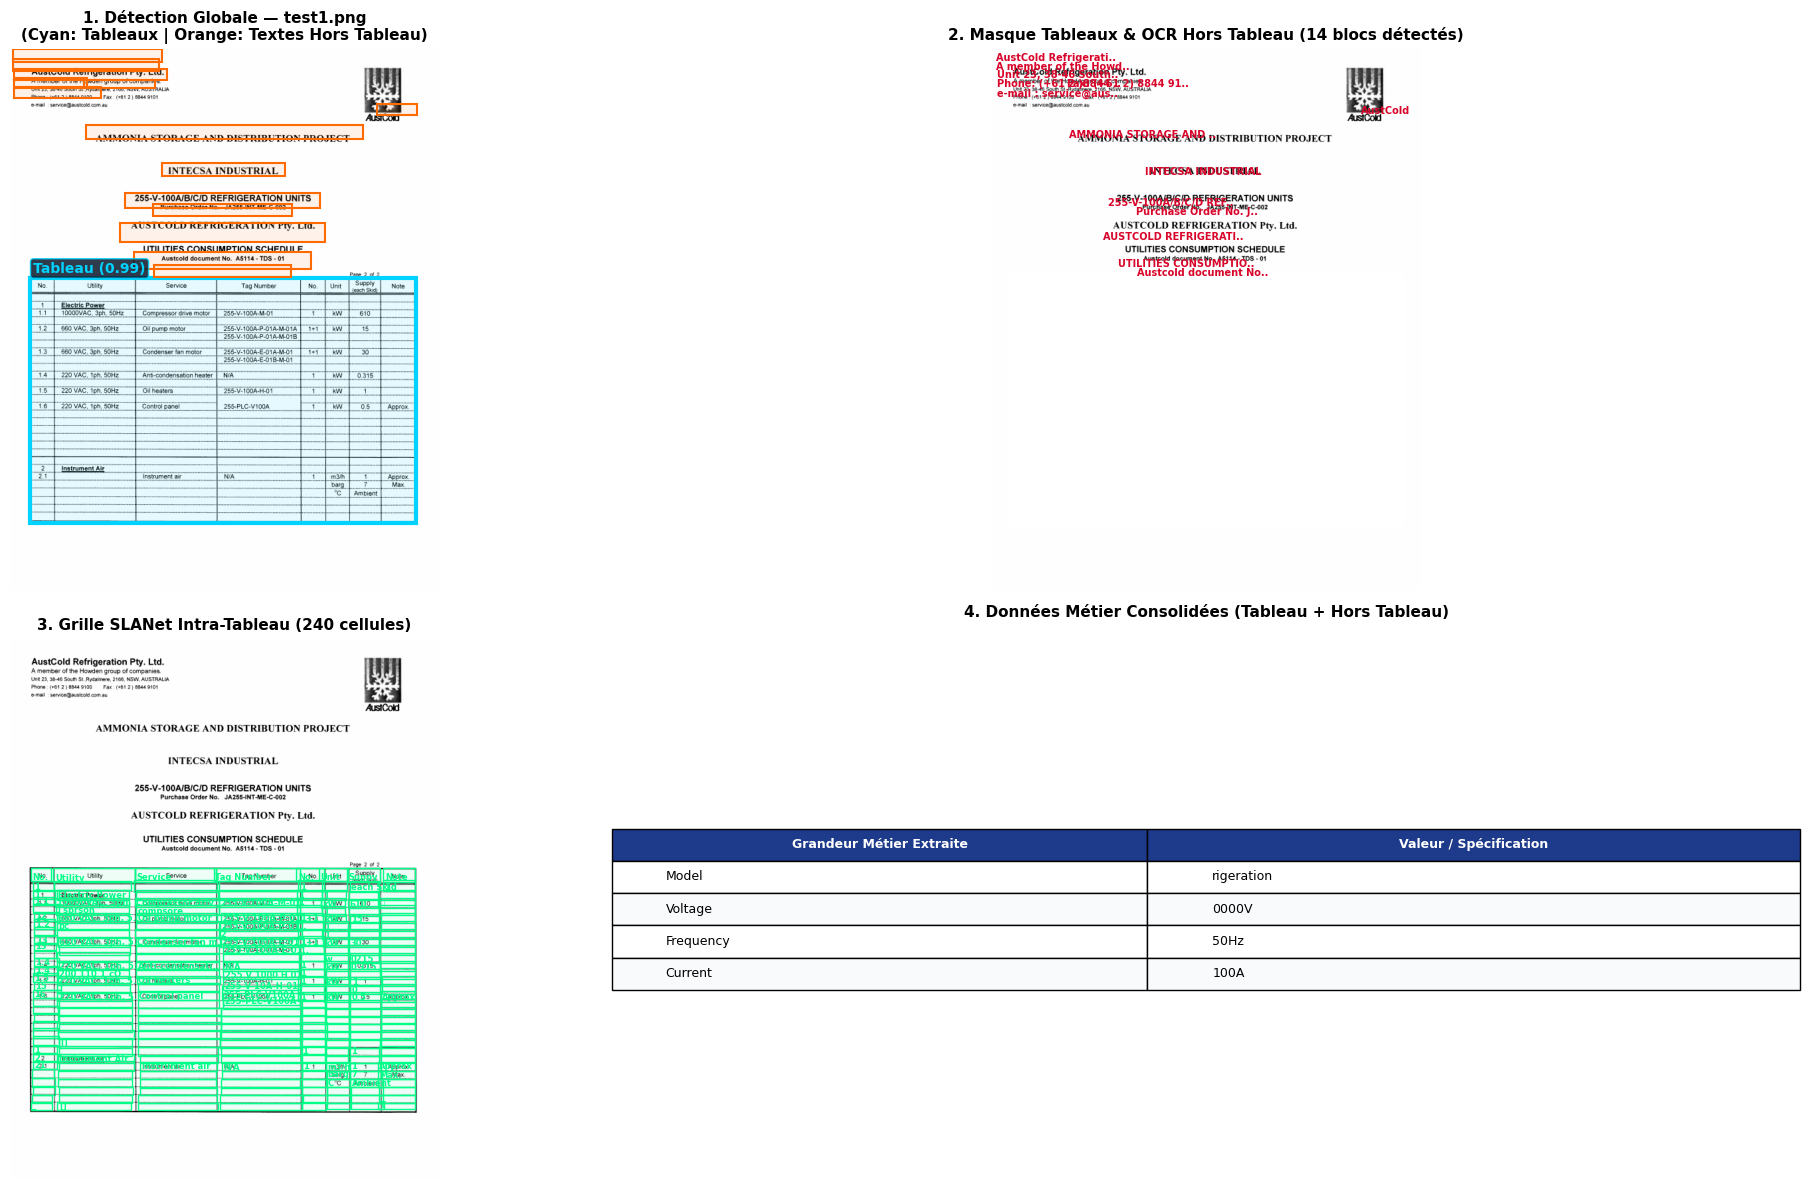


══════════════════════════════════════════════════════════════════════
 📊 Tableau Extrait (22 lignes × 8 colonnes) :
══════════════════════════════════════════════════════════════════════


,No.,Utility,Service,Tag Number,No.,Unit,Suppy,Note
0,1,,,,1,,each Skid,1
1,1,Electric Power,,,1,1,,
2,1.1,"10000VAC. 3ph, 50Hz",Compressor drive motor,255-V-100A-M-01,1,kW,610,十
3,,. sprson,compsore,,,1,,
4,12,"660 VAC, 3ph, 50Hz",Oil pump motor,255-V-100A-P-01A-M-01A,1+1,kW,15,
5,1.2,pc,,255-V-100A-P-01A-M-01B,,1,,
6,,,,2,,1,,
7,13,"660 VAC, 3ph, 50Hz",Condenser fan motor,255-V-100A-E-01A-M-01,1+1,kW,30,
8,13,,,255-V-100A-E-01B-M-01,,,,
9,,,,,,w,0215,



══════════════════════════════════════════════════════════════════════
 📝 Textes Détectés Hors Tableau (14 blocs) :
══════════════════════════════════════════════════════════════════════


,Index,Texte Extrait,Confiance,"BBox [xmin, ymin, xmax, ymax]"
0,1,AustCold Refrigeration Pty. Ltd.,100.0%,"[4, 0, 229, 20]"
1,2,A member of the Howden group of companies.,99.9%,"[4, 15, 224, 33]"
2,3,"Unit 23, 38-46 South St,Rydalmere, 2166, NSW, ...",98.4%,"[5, 30, 236, 46]"
3,4,Phone: (+61 2 )8844 9100,93.7%,"[5, 43, 115, 59]"
4,5,Fax: (+61 2) 8844 9101,95.1%,"[111, 46, 218, 59]"
5,6,e-mail : service@austcold.com.au,98.0%,"[5, 57, 136, 74]"
6,7,AustCold,99.9%,"[553, 82, 613, 100]"
7,8,AMMONIA STORAGE AND DISTRIBUTION PROJECT,100.0%,"[114, 114, 531, 136]"
8,9,INTECSA INDUSTRIAL,100.0%,"[228, 171, 413, 191]"
9,10,255-V-100A/B/C/D REFRIGERATION UNITS,100.0%,"[172, 217, 466, 239]"



══════════════════════════════════════════════════════════════════════
 🏭 Synthèse Globale des Champs Équipement Extraits (Fusion Tabulaire + Extérieur) :
══════════════════════════════════════════════════════════════════════


,Grandeur Métier,Valeur Extraite,Unité,Statut,Confiance
0,Manufacturer,—,—,Non Détecté,0%
1,Model,rigeration,—,OK Trouvé,95%
2,Serial Number,—,—,Non Détecté,0%
3,Power,—,kW,Non Détecté,0%
4,Voltage,0000V,V,OK Trouvé,95%
5,Frequency,50Hz,Hz,OK Trouvé,95%
6,Current,100A,A,OK Trouvé,95%
7,Speed,—,RPM,Non Détecté,0%
8,Efficiency Class,—,—,Non Détecté,0%
9,Protection Degree,—,—,Non Détecté,0%


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# 11.4 Démonstration Complète du Pipeline Dual OCR
# ═══════════════════════════════════════════════════════════════════════════

# Exécution sur le document de démonstration
result_dual = process_document_with_outside_ocr(SAMPLE_PDF, page_number=0, dpi=300, visualize=True)

# 1. Affichage du Tableau DataFrame intra-tableau
print("\n" + "═"*70)
print(f" 📊 Tableau Extrait ({result_dual['dataframe'].shape[0]} lignes × {result_dual['dataframe'].shape[1]} colonnes) :")
print("═"*70)
display(result_dual['dataframe'])

# 2. Affichage des Textes Détectés Hors Tableau
print("\n" + "═"*70)
print(f" 📝 Textes Détectés Hors Tableau ({len(result_dual['outside_texts'])} blocs) :")
print("═"*70)
df_outside = pd.DataFrame([{
    'Index': i+1,
    'Texte Extrait': ot['text'],
    'Confiance': f"{ot['score']*100:.1f}%",
    'BBox [xmin, ymin, xmax, ymax]': str(ot['bbox'])
} for i, ot in enumerate(result_dual['outside_texts'])])
display(df_outside)

# 3. Synthèse des Grandeurs Métier Extraites Combinées (Tableau + Hors Tableau)
print("\n" + "═"*70)
print(" 🏭 Synthèse Globale des Champs Équipement Extraits (Fusion Tabulaire + Extérieur) :")
print("═"*70)
display_equipment_summary(result_dual['extracted_fields'])
